# Getting Started With the Similarity Judgments


## Introduction
The NSD dataset includes similarity judgments collected on a shared subset of 100 images* through a multiple arrangement task. In this task, people could see all the 100 images in the same screen simultaneously, and could arrange them according to the perceived similarity. Additional details on the data collection procedure are included in the [NSD paper](https://www.nature.com/articles/s41593-021-00962-x) and in the [NSD data manual](https://cvnlab.slite.page/p/CT9Fwl4_hc/NSD-Data-Manual) (see specifically [this](https://cvnlab.slite.page/p/fRv4lz5V2F/Behavioral-data) section). Note that, both in the paper and in the data manual, these similarity judgments are referred to as the `meadows` or `nsdmeadows` data, Meadows being the tool that was used to collect the data.

*It may be that the images are in fact 103, because they may have included additional images that were expected to be interesting from the point of view of similarity ratings. 

## Where to find the data
The similarity judgments are stored in a [`json` file](https://natural-scenes-dataset.s3.amazonaws.com/nsddata/bdata/meadows/Meadows_nsd-multiple-arrangements_v_v2_tree.json). This file contains data for all participants and stores the X and Y locations of each image as arranged by the participant in the screen. 

## Figuring out image indexing
After downloading the data in the project folder, a useful initial step is to figure out the image indexing. Unfortunately, the NSD dataset can be a bit messy, as it uses MS COCO images, but often indexes them with a different indexing convention. Nevertheless, it is very important to be able to map each data point to the correct image. Hoping that the same NSD indexing convention has been used in both the fMRI experiment and this behavioural one, a mapping between indexes can be obtained running the code below (see also code from the file `src/indexing_and_formatting/image_indexing_utils.py`)

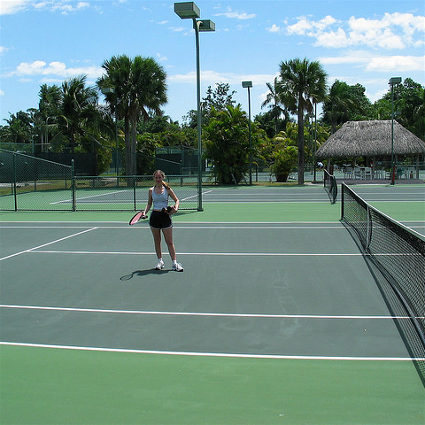

In [ ]:
## mapping NSD indexes to images
from src.paths import ROOT
from src.indexing_and_formatting.image_indexing_utils import *
from PIL import Image

# given one NSD index, like the example below, we can visualise the corresponding image as follows
nsd_index = '20703'
Image.open(ROOT / get_image_path(nsd_index))

In [6]:
get_image_path(nsd_index)

'data/images/stimuli/shared0250_nsd20703.png'

This function simply maps the NSD image index to the path that stores the image locally.

⚠️ Some NSD files use a Python indexing convention (indexing starts from `0`), while others use a Matlab convention (indexing starts from `1`). It may be good to check that the indexing convention of the similarity judgments is the same as the file naming convention in the fMRI experiments.

## Data exploration

In [1]:
from src.paths import ROOT
from src.utils import *

In [2]:
simj = open_json(ROOT / "data/similarity_judgments/simj.json")

In [3]:
simj.keys()

dict_keys(['chief-tick', 'sunny-cougar', 'mighty-squid', 'sure-kiwi', 'firm-squid', 'sacred-hen', 'moved-seal', 'still-toad'])

Nice! These creative names correspond to the 8 participants according to the following mapping, retrieved from [here](https://github.com/cvnlab/nsdcode/blob/master/nsdcode/meadows/meadows.py).

In [ ]:
subjects = {
        '1': 'chief-tick',
        '2': 'firm-squid',
        '3': 'mighty-squid',
        '4': 'sacred-hen',
        '5': 'sunny-cougar',
        '6': 'moved-seal',
        '7': 'sure-kiwi',
        '8': 'still-toad'
        }

In [4]:
simj['chief-tick'].keys()

dict_keys(['token', 'tasks'])

In [6]:
print(simj['chief-tick']['token'])

None


In [8]:
# this appears to be a list
len(simj['chief-tick']['tasks'])

14

In [26]:
for i in range(len(simj['chief-tick']['tasks'])):
    print(i, simj['chief-tick']['tasks'][i]['task'])

0 {'task_type': 'info', 'name': 'instructions'}
1 {'task_type': 'multiarrange', 'name': 'multiple-arrangements'}
2 {'task_type': 'info', 'name': 'valence-instructions'}
3 {'task_type': 'dragrate', 'name': 'valence - block 1'}
4 {'task_type': 'dragrate', 'name': 'valence - block 2'}
5 {'task_type': 'dragrate', 'name': 'valence - block 3'}
6 {'task_type': 'dragrate', 'name': 'valence - block 4'}
7 {'task_type': 'dragrate', 'name': 'valence - block 5'}
8 {'task_type': 'info', 'name': 'arousal-instructions'}
9 {'task_type': 'dragrate', 'name': 'arousal - block 1'}
10 {'task_type': 'dragrate', 'name': 'arousal - block 2'}
11 {'task_type': 'dragrate', 'name': 'arousal - block 3'}
12 {'task_type': 'dragrate', 'name': 'arousal - block 4'}
13 {'task_type': 'dragrate', 'name': 'arousal - block 5'}


Ok, it seems we are interested in task 1.

In [27]:
simj['chief-tick']['tasks'][1].keys()

dict_keys(['trials', 'task', 'next_trial_stimuli', 'status', 'qualification', 'stimuli', 'rdm'])

In [29]:
len(simj['chief-tick']['tasks'][1]['trials'])

16

In [31]:
simj['chief-tick']['tasks'][1]['trials'][0].keys()

dict_keys(['intent', 'log', 'positions', 'min_evidence'])

In [35]:
len(simj['chief-tick']['tasks'][1]['trials'][0]['positions'])

100

In [36]:
simj['chief-tick']['tasks'][1]['trials'][1].keys()

dict_keys(['intent', 'log', 'positions', 'min_evidence'])

In [47]:
n_images = 0
for i in range(1, 16):
    im_per_trial = len(simj['chief-tick']['tasks'][1]['trials'][i]['positions'])
    print(im_per_trial)
    n_images += im_per_trial
n_images

19
14
17
5
18
18
20
12
10
12
7
6
7
8
12


185

I have the impression that trial 0 is a sort of integration across trials. 

In [49]:
len(simj['chief-tick']['tasks'][1]['rdm'])

4950

In [50]:
(100 * 100 - 100) / 2

4950.0

Ok, this seems to be the full RDM for the 100 images.

In [53]:
simj['chief-tick']['tasks'][1]['stimuli'][0]

{'size': 384617,
 'id': '78985f4d91620a9a70d72434f98a0e5a',
 'type': 'png',
 'name': 'shared0004_nsd03078'}